## Часть с kagle

In [1]:
import os
dataset_dir = './dataset'

os.listdir(dataset_dir)

['test', 'test.csv', 'train']

In [2]:
training_dir = f"{dataset_dir}/train"
files = os.listdir(training_dir)

In [3]:
is_json = lambda x: x.endswith("json")
is_img = lambda x: x.endswith("jpg")

In [4]:
import json
coco_json = next(filter(is_json, files))

In [5]:
with open(f"{training_dir}/{coco_json}") as coco_file:
    coco_json = json.load(coco_file)
    # print(coco_json.keys())
    coco_annotations = coco_json.get("annotations")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import cv2
from matplotlib.patches import Rectangle

In [7]:
categories = coco_json['categories']
category_map = {cat['id']: cat['name'] for cat in categories}


category_counts = {cat['id']: 0 for cat in categories}

for ann in coco_json['annotations']:
    category_counts[ann['category_id']] += 1

In [8]:
categories

[{'id': 0, 'name': 'football-objects', 'supercategory': 'none'},
 {'id': 1, 'name': 'ball', 'supercategory': 'football-objects'},
 {'id': 2, 'name': 'coach', 'supercategory': 'football-objects'},
 {'id': 3, 'name': 'goalkeeper', 'supercategory': 'football-objects'},
 {'id': 4, 'name': 'player', 'supercategory': 'football-objects'},
 {'id': 5, 'name': 'referee', 'supercategory': 'football-objects'}]

In [9]:
class_distribution = pd.DataFrame([
    {'category_id': cat_id, 'category_name': category_map[cat_id], 'count': count} 
    for cat_id, count in category_counts.items()
])

# Sort by count
class_distribution = class_distribution.sort_values('count', ascending=False)

class_distribution

,category_id,category_name,count
4,4,player,12261
5,5,referee,1321
1,1,ball,739
3,3,goalkeeper,281
2,2,coach,202
0,0,football-objects,0


## Фирменная реализация функции отрисовки bb от Ивана

In [10]:
labels = labels = {1: 'ball', 2: 'coach', 3: 'goalkeeper', 4: 'player', 5: 'referee'}

def draw_bounding_boxes(coco_json, image_path, image_id):
    file_name = None
    for i in coco_json['images']:
        if i["id"] == image_id:
            file_name = i['file_name']
            break

    if file_name is None:
        raise FileNotFoundError(f"Не удалось найти id изображения: {image_id}")

    image_path_full = image_path + file_name

    image_boxes = []
    for i in coco_json['annotations']:
        if i["image_id"] == image_id:
            image_boxes.append(i)

    # Загрузка изображения
    img = cv2.imread(image_path_full)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {image_path_full}")
    
    # Конвертируем BGR в RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img_rgb)
    
    for i in image_boxes:
        bbox = i["bbox"]
        x_min, y_min, width, height = bbox
        x_max = x_min + width
        y_max = y_min + height
        
        rect = Rectangle((x_min, y_min), width, height, 
                        linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        
        if "category_id" in i:
            ax.text(x_min, y_min - 5, f'{labels[i["category_id"]]}', 
                   color='white', fontsize=10, 
                   bbox=dict(facecolor='red', alpha=0.7))
    
    ax.set_title(f'Image ID: {image_id} | BBoxes: {len(image_boxes)}')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()


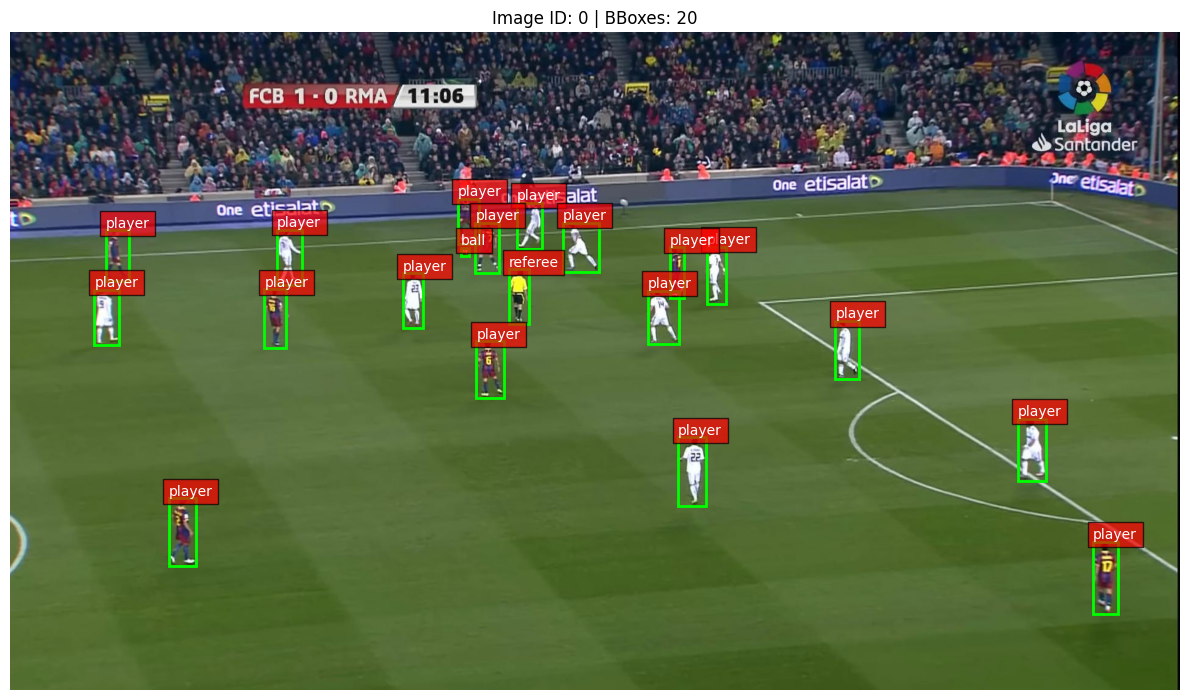

In [11]:
image_path = "./dataset/train/"

draw_bounding_boxes(coco_json, image_path, 0)

# Обучение на YOLO

# Перевод данных в формат YOLO

здесь внимательно заменить все пути к данным... (временные трудности)

In [12]:
import json
import os
import shutil
import yaml
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm

# Загружаем JSON файл с аннотациями
with open('./dataset/train/_annotations.coco.json', 'r') as f:
    coco_json = json.load(f)

print(f"Загружено {len(coco_json['images'])} изображений")
print(f"Загружено {len(coco_json['annotations'])} аннотаций")
print(f"Классы: {[cat['name'] for cat in coco_json['categories']]}")

# Создаем директории для YOLO формата
def create_yolo_structure(base_path='./yolo_football'):
    """Создает структуру папок для YOLO"""
    directories = [
        f'{base_path}/train/images',
        f'{base_path}/train/labels',
        f'{base_path}/val/images',
        f'{base_path}/val/labels',
        f'{base_path}/test/images',
        f'{base_path}/test/labels',
    ]
    
    for dir_path in directories:
        os.makedirs(dir_path, exist_ok=True)
    
    print(f"Создана структура папок в {base_path}")

    return base_path

# Функция для конвертации COCO в YOLO формат
def convert_coco_to_yolo(img_info, annotations, output_dir, split='train'):
    """
    Конвертирует одно изображение из COCO в YOLO формат
    
    Args:
        img_info: информация об изображении из coco_json['images']
        annotations: список аннотаций для этого изображения
        output_dir: базовая директория вывода
        split: 'train' или 'val'
    """
    # Путь к исходному изображению
    src_image_path = f"./dataset/{split}/{img_info['file_name']}"
    
    if not os.path.exists(src_image_path):
        # Пробуем найти в train если не нашли в указанном split
        src_image_path = f"./dataset/train/{img_info['file_name']}"
    
    if not os.path.exists(src_image_path):
        print(f"Изображение не найдено: {img_info['file_name']}")
        return False
    
    # Копируем изображение
    dst_image_path = f"{output_dir}/{split}/images/{img_info['file_name']}"
    shutil.copy2(src_image_path, dst_image_path)
    
    # Создаем YOLO аннотацию
    img_width = img_info['width']
    img_height = img_info['height']
    
    # Создаем файл с метками
    label_filename = os.path.splitext(img_info['file_name'])[0] + '.txt'
    label_path = f"{output_dir}/{split}/labels/{label_filename}"
    
    with open(label_path, 'w') as f:
        for ann in annotations:
            # COCO формат: [x_min, y_min, width, height]
            x_min, y_min, width, height = ann['bbox']
            
            # Конвертируем в YOLO формат: [class_id, x_center, y_center, width, height]
            # Все значения нормализуем относительно размеров изображения
            x_center = (x_min + width / 2) / img_width
            y_center = (y_min + height / 2) / img_height
            width_norm = width / img_width
            height_norm = height / img_height
            
            # COCO category_id обычно начинается с 1, делаем 0-based
            class_id = ann['category_id']
            
            # Записываем в файл
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")
    
    return True

# Основная функция подготовки
def prepare_yolo_dataset(test_size=0.2, random_state=42):
    """Основная функция подготовки данных для YOLO"""
    
    # Создаем структуру папок
    base_path = create_yolo_structure('./yolo_football_dataset')
    
    # Создаем mapping для быстрого поиска аннотаций
    annotations_by_image = {}
    for ann in coco_json['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)
    
    # Создаем словарь изображений
    images_by_id = {img['id']: img for img in coco_json['images']}
    
    # Разделяем на train/val
    image_ids = list(images_by_id.keys())
    train_ids, val_ids = train_test_split(
        image_ids, 
        test_size=test_size, 
        random_state=random_state
    )
    
    print(f"\nРазделение данных:")
    print(f"  Train: {len(train_ids)} изображений")
    print(f"  Val:   {len(val_ids)} изображений")
    
    print("\nОбработка train данных...")
    train_success = 0
    for img_id in tqdm(train_ids):
        img_info = images_by_id[img_id]
        annotations = annotations_by_image.get(img_id, [])
        
        if convert_coco_to_yolo(img_info, annotations, base_path, split='train'):
            train_success += 1
    
    print("\nОбработка val данных...")
    val_success = 0
    for img_id in tqdm(val_ids):
        img_info = images_by_id[img_id]
        annotations = annotations_by_image.get(img_id, [])
        
        if convert_coco_to_yolo(img_info, annotations, base_path, split='val'):
            val_success += 1
    
    print(f"\nОбработано успешно:")
    print(f"   Train: {train_success}/{len(train_ids)}")
    print(f"   Val:   {val_success}/{len(val_ids)}")
    
    # 5. Создаем dataset.yaml
    create_dataset_yaml(coco_json, base_path)
    
    return base_path

def create_dataset_yaml(coco_data, base_path):
    """Создает dataset.yaml файл для YOLO"""
    
    # Получаем имена классов в правильном порядке
    categories_sorted = sorted(coco_data['categories'], key=lambda x: x['id'])
    class_names = [cat['name'] for cat in categories_sorted]
    
    # Создаем конфигурацию
    config = {
        'path': os.path.abspath(base_path),  # Абсолютный путь
        'train': 'train/images',  # Относительно path
        'val': 'val/images',      # Относительно path
        
        # Количество классов
        'nc': len(class_names),
        
        # Имена классов
        'names': class_names
    }
    
    # Сохраняем YAML файл
    yaml_path = os.path.join(base_path, 'dataset.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    
    print(f"\nСоздан файл конфигурации: {yaml_path}")
    print(f"   Classes: {class_names}")
    
    return yaml_path

# 6. Функция для проверки конвертации
def verify_conversion(sample_image_id):
    """Проверяет правильность конвертации на примере"""
    
    # Находим изображение
    img_info = None
    for img in coco_json['images']:
        if img['id'] == sample_image_id:
            img_info = img
            break
    
    if not img_info:
        print(f"Image ID {sample_image_id} not found")
        return
    
    # Получаем аннотации
    annotations = []
    for ann in coco_json['annotations']:
        if ann['image_id'] == sample_image_id:
            annotations.append(ann)
    
    # Загружаем исходное изображение
    src_path = f"./dataset/train/{img_info['file_name']}"
    img = cv2.imread(src_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Рисуем bounding boxes из COCO
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Оригинальные COCO bboxes
    img_coco = img_rgb.copy()
    for ann in annotations:
        x_min, y_min, width, height = map(int, ann['bbox'])
        x_max = x_min + width
        y_max = y_min + height
        
        # Рисуем прямоугольник
        cv2.rectangle(img_coco, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        
        # Добавляем текст с классом
        class_name = next((cat['name'] for cat in coco_json['categories'] 
                          if cat['id'] == ann['category_id']), 'unknown')
        cv2.putText(img_coco, class_name, (x_min, y_min - 10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    axes[0].imshow(img_coco)
    axes[0].set_title('Original COCO Annotations')
    axes[0].axis('off')
    
    # Загружаем YOLO аннотацию и рисуем
    yolo_label_path = f"./yolo_football_dataset/train/labels/{os.path.splitext(img_info['file_name'])[0]}.txt"
    
    if os.path.exists(yolo_label_path):
        img_yolo = img_rgb.copy()
        img_height, img_width = img_rgb.shape[:2]
        
        with open(yolo_label_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x_center, y_center, w_norm, h_norm = map(float, parts)
                
                # Конвертируем обратно в пиксельные координаты
                x_center_px = x_center * img_width
                y_center_px = y_center * img_height
                w_px = w_norm * img_width
                h_px = h_norm * img_height
                
                x_min = int(x_center_px - w_px / 2)
                y_min = int(y_center_px - h_px / 2)
                x_max = int(x_center_px + w_px / 2)
                y_max = int(y_center_px + h_px / 2)
                
                # Рисуем
                cv2.rectangle(img_yolo, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)
                
                # Получаем имя класса
                class_name = coco_json['categories'][int(class_id)]['name']
                cv2.putText(img_yolo, class_name, (x_min, y_min - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
        axes[1].imshow(img_yolo)
        axes[1].set_title('YOLO Format Annotations')
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'YOLO file not found yet\nRun prepare_yolo_dataset() first', 
                    ha='center', va='center', fontsize=12)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# 7. Запуск подготовки данных
if __name__ == "__main__":
    print("=" * 60)
    print("ПОДГОТОВКА ДАННЫХ ДЛЯ YOLOv8")
    print("=" * 60)
    
    # Подготавливаем данные
    dataset_path = prepare_yolo_dataset(test_size=0.2, random_state=42)
    
    print("\n" + "=" * 60)
    print("ДАННЫЕ ГОТОВЫ!")
    print("=" * 60)
    
    print(f"\nСтруктура датасета:")
    print(f"   {dataset_path}/")
    print(f"   ├── train/")
    print(f"   │   ├── images/    # {len(os.listdir(f'{dataset_path}/train/images'))} файлов")
    print(f"   │   └── labels/    # {len(os.listdir(f'{dataset_path}/train/labels'))} файлов")
    print(f"   ├── val/")
    print(f"   │   ├── images/    # {len(os.listdir(f'{dataset_path}/val/images'))} файлов")
    print(f"   │   └── labels/    # {len(os.listdir(f'{dataset_path}/val/labels'))} файлов")
    print(f"   └── dataset.yaml   # конфигурационный файл")
    
    print(f"\nДля обучения запустите:")
    print(f"   from ultralytics import YOLO")
    print(f"   model = YOLO('yolov8s.pt')")
    print(f"   model.train(data='{dataset_path}/dataset.yaml', epochs=100, imgsz=640)")

Загружено 800 изображений
Загружено 14804 аннотаций
Классы: ['football-objects', 'ball', 'coach', 'goalkeeper', 'player', 'referee']
ПОДГОТОВКА ДАННЫХ ДЛЯ YOLOv8
Создана структура папок в ./yolo_football_dataset

Разделение данных:
  Train: 640 изображений
  Val:   160 изображений

Обработка train данных...


100%|██████████| 640/640 [00:01<00:00, 551.85it/s]



Обработка val данных...


100%|██████████| 160/160 [00:00<00:00, 511.76it/s]


Обработано успешно:
   Train: 640/640
   Val:   160/160

Создан файл конфигурации: ./yolo_football_dataset\dataset.yaml
   Classes: ['football-objects', 'ball', 'coach', 'goalkeeper', 'player', 'referee']

ДАННЫЕ ГОТОВЫ!

Структура датасета:
   ./yolo_football_dataset/
   ├── train/
   │   ├── images/    # 640 файлов
   │   └── labels/    # 640 файлов
   ├── val/
   │   ├── images/    # 160 файлов
   │   └── labels/    # 160 файлов
   └── dataset.yaml   # конфигурационный файл

Для обучения запустите:
   from ultralytics import YOLO
   model = YOLO('yolov8s.pt')
   model.train(data='./yolo_football_dataset/dataset.yaml', epochs=100, imgsz=640)



Проверка конвертации (первые 2 изображения):


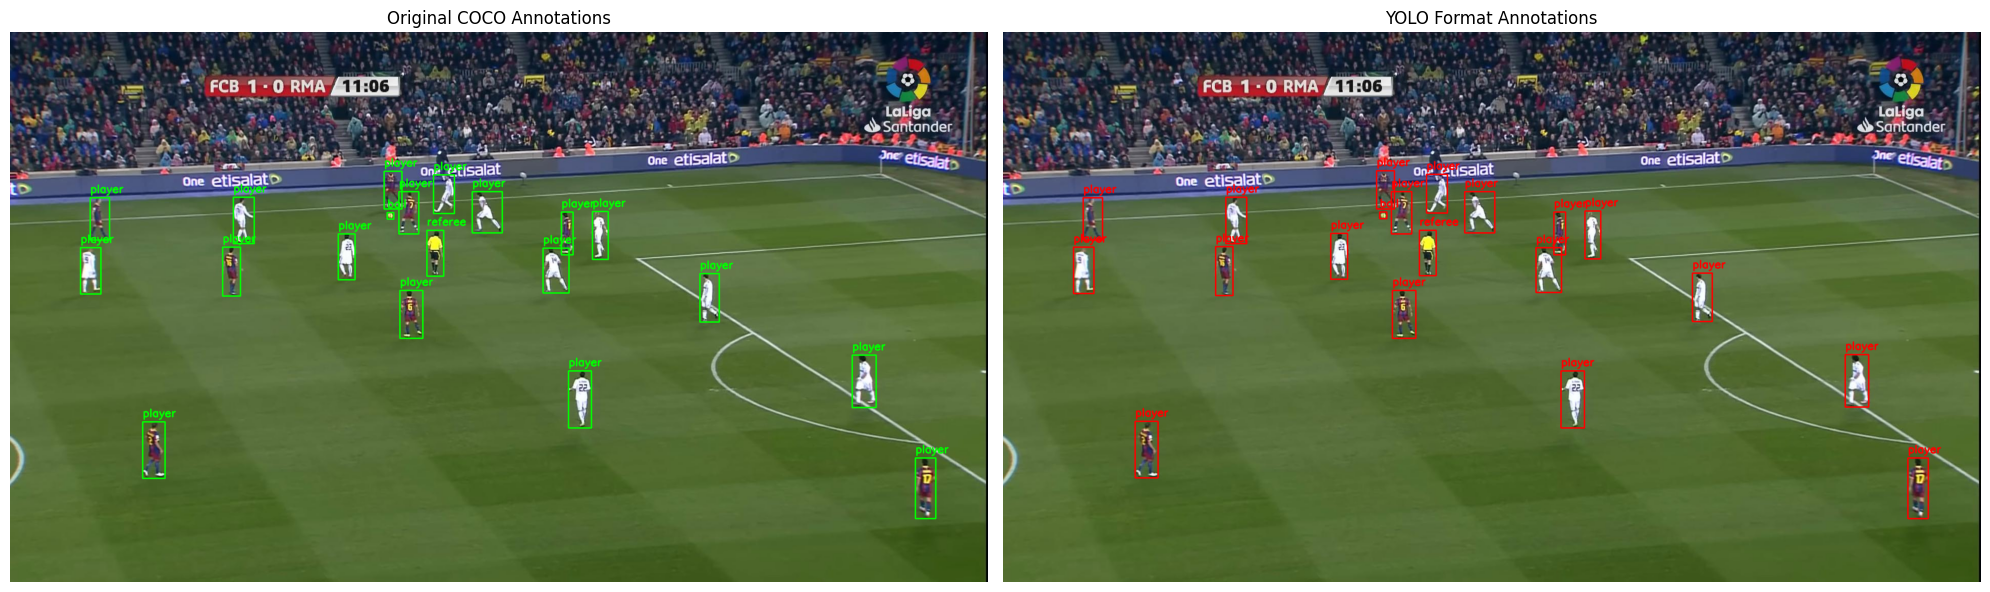

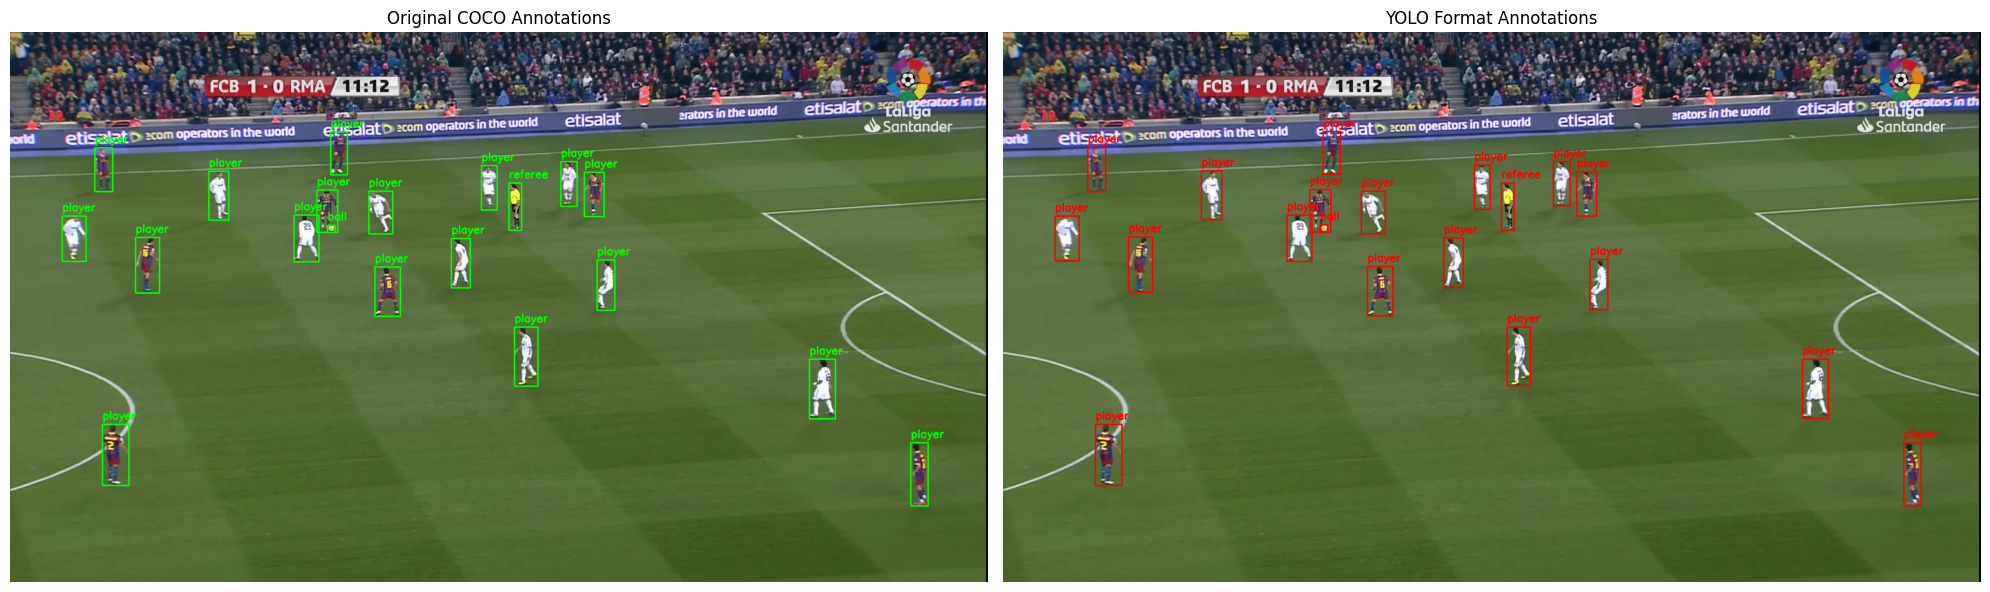

In [13]:
print(f"\nПроверка конвертации (первые 2 изображения):")

sample_ids = list(coco_json['images'])[:2]
for img_info in sample_ids:
    verify_conversion(img_info['id'])
# Тут не всега будут выходить левые рисунки, так как возможно они попали в val, и просто не найдутся
# Главное посмотреть, чтобы классы правильно перешли (игроки - к игрокам и тд и тп)

## Обучение YOLO

просто запустить...

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
results = model.train(data='./yolo_football_dataset/dataset.yaml', epochs=16, imgsz=640, model='yolov8s.pt', workers=0, cache=False)

New https://pypi.org/project/ultralytics/8.3.239 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.13.7 torch-2.8.0+cpu CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_football_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=16, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=6

c:\Users\User\anaconda3\envs\neural_networks\Lib\site-packages\clearml\binding\import_bind.py:64: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = builtins.__org_import__(name, globals=globals, locals=locals, fromlist=fromlist, level=level)


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.00.0 ms, read: 12.33.1 MB/s, size: 148.5 KB)
val: Scanning C:\Users\User\VsCodeProjects\designing_neural_network_architectures_2025_01\DesigningNN-project\model\yolo_football_dataset\val\labels... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 346.4it/s 0.5s0.0s
val: New cache created: C:\Users\User\VsCodeProjects\designing_neural_network_architectures_2025_01\DesigningNN-project\model\yolo_football_dataset\val\labels.cache
Plotting labels to C:\Users\User\VsCodeProjects\designing_neural_network_architectures_2025_01\DesigningNN-project\model\runs\detect\train2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
opti

## Предикты

In [ ]:
result = model.predict('D:\model_descriptor\ML_MAGA\project\dataset\\test\\frame_001064_png.rf.fb03f13c3d2a3b52ac100f10a4948337.jpg', save=True


image 1/1 D:\model_descriptor\ML_MAGA\project\dataset\test\frame_001064_png.rf.fb03f13c3d2a3b52ac100f10a4948337.jpg: 384x640 1 ball, 16 players, 1 referee, 56.3ms
Speed: 3.1ms preprocess, 56.3ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to D:\model_descriptor\ML_MAGA\project\runs\detect\predict


# R-CNN

In [1]:
import os
import json
import random
import torch
import torchvision
import cv2
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm.auto import tqdm


c:\Users\User\anaconda3\envs\neural_networks\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = "./dataset/train"
ANN_PATH = os.path.join(BASE_PATH, "_annotations.coco.json")
IMG_DIR = BASE_PATH

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 10
BATCH_SIZE = 4
LR = 1e-4

In [3]:
# COCO category_id -> contiguous labels for Faster R-CNN
CLASS_MAP = {
    1: 1,  # ball
    2: 2,  # coach
    3: 3,  # goalkeeper
    4: 4,  # player
    5: 5,  # referee
}

NUM_CLASSES = 6  # 5 классов + background


In [4]:
class COCOFootballDataset(Dataset):
    def __init__(self, img_dir, ann_path, image_ids, class_map):
        with open(ann_path) as f:
            coco = json.load(f)

        self.img_dir = img_dir
        self.class_map = class_map

        self.images = {img["id"]: img for img in coco["images"]}
        self.annotations = {}

        for ann in coco["annotations"]:
            if ann["image_id"] not in self.annotations:
                self.annotations[ann["image_id"]] = []
            self.annotations[ann["image_id"]].append(ann)

        self.ids = image_ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.images[img_id]

        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        boxes = []
        labels = []

        for ann in self.annotations.get(img_id, []):
            if ann["category_id"] not in self.class_map:
                continue

            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(self.class_map[ann["category_id"]])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
        }

        img = F.to_tensor(img)
        return img, target

In [5]:
with open(ANN_PATH) as f:
    coco = json.load(f)

all_image_ids = [img["id"] for img in coco["images"]]
random.shuffle(all_image_ids)

split_idx = int(0.8 * len(all_image_ids))
train_ids = all_image_ids[:split_idx]
val_ids = all_image_ids[split_idx:]

print(f"Train images: {len(train_ids)}")
print(f"Val images:   {len(val_ids)}")


Train images: 640
Val images:   160


In [6]:
def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = COCOFootballDataset(
    IMG_DIR,
    ANN_PATH,
    train_ids,
    CLASS_MAP
)

val_dataset = COCOFootballDataset(
    IMG_DIR,
    ANN_PATH,
    val_ids,
    CLASS_MAP
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)


In [7]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

model.to(DEVICE)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)


In [9]:
for epoch in range(EPOCHS):
    model.train()

    pbar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{EPOCHS}]",
        leave=True
    )

    epoch_loss = 0.0

    for images, targets in pbar:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        epoch_loss += loss_value

        pbar.set_postfix({
            "loss": f"{loss_value:.4f}"
        })

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Average Loss: {avg_loss:.4f}")

Epoch [1/10]: 100%|██████████| 160/160 [38:01<00:00, 14.26s/it, loss=0.4878]


Epoch [1/10] Average Loss: 0.6588


Epoch [2/10]: 100%|██████████| 160/160 [37:36<00:00, 14.10s/it, loss=0.4220]


Epoch [2/10] Average Loss: 0.4180


Epoch [3/10]: 100%|██████████| 160/160 [37:50<00:00, 14.19s/it, loss=0.3552]


...

Epoch [8/10] Average Loss: 0.2372


Epoch [9/10]: 100%|██████████| 160/160 [37:53<00:00, 14.21s/it, loss=0.2750]


Epoch [9/10] Average Loss: 0.2276


Epoch [10/10]: 100%|██████████| 160/160 [37:54<00:00, 14.22s/it, loss=0.2309]

Epoch [10/10] Average Loss: 0.2143


In [10]:
os.makedirs("runs/weights", exist_ok=True)

torch.save(
    model.state_dict(),
    "runs/weights/fasterrcnn_football_coco.pt"
)

print("Model saved: runs/weights/fasterrcnn_football_coco.pt")


Model saved: runs/weights/fasterrcnn_football_coco.pt


In [ ]:
model.eval()

img, _ = val_dataset[0]
img = img.to(DEVICE)

with torch.no_grad()
    output = model([img])[0]

print(output.keys())
print("Boxes:", output["boxes"][:5])
print("Scores:", output["scores"][:5])
print("Labels:", output["labels"][:5])

dict_keys(['boxes', 'labels', 'scores'])
Boxes: tensor([[374.7616, 752.0306, 423.9923, 858.7552],
        [451.2989, 380.5106, 504.9277, 472.5778],
        [336.8113, 524.5087, 386.8732, 618.7636],
        [731.4664, 401.5437, 763.4526, 485.8963],
        [348.0650, 576.8453, 399.0288, 694.7603]])
Scores: tensor([0.9994, 0.9993, 0.9989, 0.9989, 0.9987])
Labels: tensor([4, 4, 4, 4, 4])


In [12]:
CLASS_NAMES = {
    1: "ball",
    2: "coach",
    3: "goalkeeper",
    4: "player",
    5: "referee",
}

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [14]:
def visualize_detection(
    image_tensor,
    output,
    score_threshold=0.5
):
    """
    image_tensor: torch.Tensor (3, H, W)
    output: model([image])[0]
    """

    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)
    ax.axis("off")

    boxes = output["boxes"].cpu()
    scores = output["scores"].cpu()
    labels = output["labels"].cpu()

    for box, score, label in zip(boxes, scores, labels):
        if score < score_threshold:
            continue

        x1, y1, x2, y2 = box.tolist()
        width = x2 - x1
        height = y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        class_name = CLASS_NAMES.get(label.item(), "unknown")
        ax.text(
            x1,
            y1 - 5,
            f"{class_name} {score:.2f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.7, pad=2),
        )

    plt.show()


In [21]:
TEST_IMG_DIR = "dataset/test/"

img_name = os.listdir(TEST_IMG_DIR)[21]
img_path = os.path.join(TEST_IMG_DIR, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_tensor = F.to_tensor(img).to(DEVICE)

Detected objects: 10


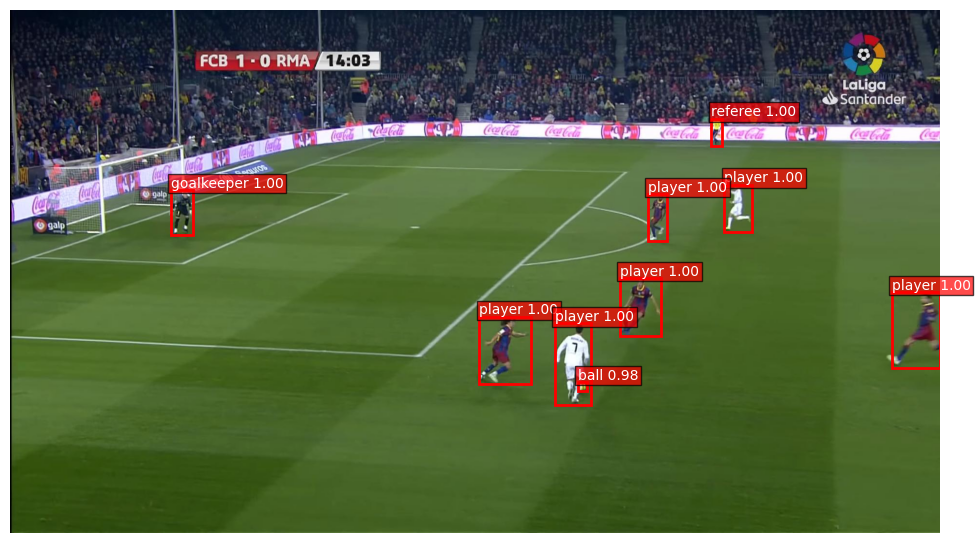

In [22]:
model.eval()

with torch.no_grad():
    output = model([img_tensor])[0]

print("Detected objects:", len(output["boxes"]))

visualize_detection(
    img_tensor,
    output,
    score_threshold=0.6
)
